### 학습목표
- 개, 고양이 이미지(사진)을 분류하는 CNN 신경망 실습을 진행해보자
- CNN 알고리즘에 대해여 알 수 있다.
- npz 파일을 다루는 방법에 대해 알 수 있다.

- npz: numpy 배열에서 제공하는 파일 형식 -> 여러개의 numpy 배열을 하나의 압축된 파일로 저장하여 공유
- 대용량의 데이터를 압축형태로 정리하여 저장공간 효율, 빠른 공유 가능

In [12]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [13]:
# 구글마운트
%cd /content/drive/MyDrive/Colab Notebooks/2. 수업/26.02 LG전자DX스쿨(5기)/3. 딥러닝

/content/drive/MyDrive/Colab Notebooks/2. 수업/26.02 LG전자DX스쿨(5기)/3. 딥러닝


In [14]:
#npz 파일 불러오기
data = np.load('./data/np_cats_dogs.npz')
data

NpzFile './data/np_cats_dogs.npz' with keys: X_train, X_test, y_train, y_test

In [15]:
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

### 모델 비교
- MLP 모델링
  - 이진분류 (mlp_model)
  - 3층(256,128,64), 활성화함수: relu, 최적화함수: adam
- CNN 모델링

In [ ]:
# 모델링 라이브러리 불러오기
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D, MaxPooling2D
# Conv2D: 이미지에서 특징을 추출하는 기능을 하는 층 설계시 사용
# MaxPooling2D: 이미지의 크기를 줄여주는 기능, 특징이 아닌 부분 삭제
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
X_train.shape

(2000, 224, 224, 3)

In [ ]:
# MLP 모델링 진행하기!!!
mlp_model = Sequential()
mlp_model.add(Input(shape = (224,224,3)))
mlp_model.add(Flatten())
mlp_model.add(Dense(units = 256, activation='relu'))
mlp_model.add(Dense(units = 128, activation='relu'))
mlp_model.add(Dense(units = 64, activation='relu'))
mlp_model.add(Dense(units = 1, activation='sigmoid'))

mlp_model.compile(loss = 'binary_crossentropy', optimizer = Adam(), metrics = ['accuracy'])
mlp_model.fit(X_train, y_train, epochs = 20, validation_split = 0.2)

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.5456 - loss: 1016.5444 - val_accuracy: 0.0000e+00 - val_loss: 2893.4438
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5663 - loss: 629.2716 - val_accuracy: 0.0000e+00 - val_loss: 807.0602
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5425 - loss: 489.4872 - val_accuracy: 0.0050 - val_loss: 1000.6494
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5612 - loss: 336.0648 - val_accuracy: 0.0025 - val_loss: 812.7068
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6006 - loss: 108.4718 - val_accuracy: 0.9425 - val_loss: 4.4217
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6319 - loss: 49.3143 - val_accuracy: 0.3775 - val_loss: 61.3360
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5775 - loss: 83.2054 - val_accuracy: 0.0000e+00 - val_loss: 687.7756
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5775 - l

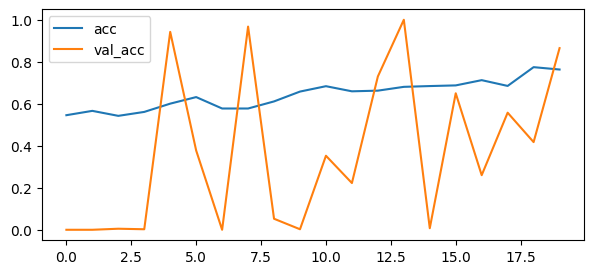

In [ ]:
# 시각화 -> accuracy
plt.figure(figsize = (7,3))
plt.plot(mlp_model.history.history['accuracy'], label = 'acc')
plt.plot(mlp_model.history.history['val_accuracy'], label = 'val_acc')
plt.legend()
plt.show()


### CNN 모델링 (Convolutional Neutal Network)
- 주로 이미지 데이터 분석에 사용하는 알고리즘
- 데이터의 특징을 추출하여 학습에 사용 (공간적인 구조를 가진 데이터셋)
- 층 구성
  - 특성추출부
    - Conv2D: 이미지의 특성을 추출
    - Pooling: 특성이 아닌부분을 삭제 (크기를 줄여 연산량을 줄이기 위함)
    - Flatten: 2차원데이터를 1차원으로 변경
  - 분류부(분석부)
    - Dense: 추출한 특성을 연산하여 클래스의 확률을 계산
    - Dense: 출력층 (학습유형에 따라 설계, 이진분류, 다중분류 다르게 설정)

- cnn_model.add(Conv2D(input_shape = (224,224,3), filters = 32, kernel_size = (3,3),
                     activation = 'relu', strides = (2,2), padding = 'same'))
  - input_shape: 입력데이터 형태(행,열, 색상차원) -> 첫 레이어에서만 정의
  - filters: 필터의 수, 돋보기의 수
  - kernel_size : 필터사이즈 (행,열)
  - activation : 활성화함수 -> 추가연산
  - strides: 커널을 이동시키는 보폭 (행,열)
  - padding: 데이터의 경계처리 방식을 정의
    - valid: 유효한 영역 출력
    - same: 출력데이터의 크기를 입력이미지의 사이즈와 동일하도록 설정 -> 테두리에 0값을 둘러 연산
  - strides, kernel 크기에 따라 출력결과가 달라짐
  - 중요한특성을 추출하는것이 주 목적!!

In [ ]:
# 뼈대생성
cnn_model = Sequential()
# 특성추출부
cnn_model.add(Conv2D(input_shape = (224,224,3), filters = 32, kernel_size = (3,3),
                     activation = 'relu', strides = (2,2), padding = 'same'))
cnn_model.add(MaxPooling2D())
cnn_model.add(Conv2D(filters = 32, kernel_size = (3,3),
                     activation = 'relu', strides = (2,2), padding = 'same'))
cnn_model.add(MaxPooling2D())
cnn_model.add(Conv2D(filters = 64, kernel_size = (3,3),
                     activation = 'relu', strides = (2,2), padding = 'same'))
cnn_model.add(MaxPooling2D())
cnn_model.add(Flatten())
# 분류부(분석부)
cnn_model.add(Dense(units = 512, activation = 'relu')) # 중간층
cnn_model.add(Dense(units = 1, activation = 'sigmoid')) # 출력층

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn_model.compile(loss = 'binary_crossentropy', optimizer = Adam(), metrics = ['accuracy'])
cnn_model.fit(X_train, y_train, epochs = 20, validation_split = 0.2)

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.5594 - loss: 3.4004 - val_accuracy: 0.1375 - val_loss: 1.0859
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6338 - loss: 0.6527 - val_accuracy: 0.3925 - val_loss: 0.8542
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6831 - loss: 0.5990 - val_accuracy: 0.6900 - val_loss: 0.5513
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7075 - loss: 0.5536 - val_accuracy: 0.3875 - val_loss: 0.9087
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7212 - loss: 0.5571 - val_accuracy: 0.5400 - val_loss: 0.7033
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7550 - loss: 0.4990 - val_accuracy: 0.5350 - val_loss: 0.7943
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7975 - loss: 0.4220 - val_accuracy: 0.3025 - val_loss: 1.2840
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8406 - loss: 0.3664 - val_accuracy: 0.5200 - v

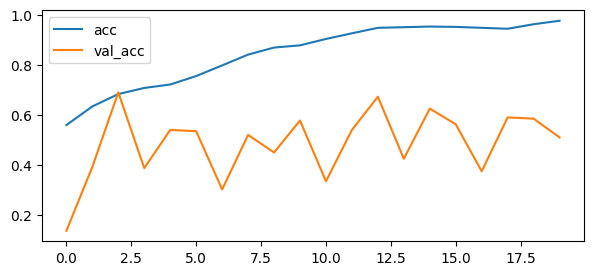

In [ ]:
plt.figure(figsize = (7,3))
plt.plot(cnn_model.history.history['accuracy'], label = 'acc')
plt.plot(cnn_model.history.history['val_accuracy'], label = 'val_acc')
plt.legend()
plt.show()

### 모델의 성능을 향상시키는 방법
1. 이미지 증식
  - 한개의 이미지를 다양한 형태로 변경하여 데이터를 추가하는 방법
  - 확대, 축소, 회전, 반전 등
  | **매개변수**          | **설명**                                                                 |
|-----------------------|-------------------------------------------------------------------------|
| `rescale`             | 픽셀 값을 스케일링 (예: `rescale=1./255`로 0~1로 정규화).               |
| `rotation_range`      | 이미지를 일정 각도로 회전 (0~360도).                                    |
| `width_shift_range`   | 이미지를 가로 방향으로 이동 (비율).                                     |
| `height_shift_range`  | 이미지를 세로 방향으로 이동 (비율).                                     |
| `shear_range`         | 이미지를 전단(비틀기).                                                  |
| `zoom_range`          | 이미지를 확대/축소.                                                    |
| `horizontal_flip`     | 이미지를 좌우 반전.                                                    |
| `vertical_flip`       | 이미지를 상하 반전.                                                    |
| `fill_mode`           | 변형 시 생기는 빈 공간을 채우는 방식 (`nearest`, `constant`, `reflect`, `wrap`). |


2. 전이학습 (Transfer Learning)
- 기존에 학습되어있는 모델을 활용
  - 추가학습을 통하여 나만의 모델로 재학습 후 사용
- 장점
  - 적은데이터로도 충분히 좋은 성능
  - 학습속도가 빠르다 (추가데이터셋만 학습)
  - 학습할 데이터셋의 초기특징을 추출하는 학습시간이 줄어듦

- 예시
  - 우리의 분류 class: 개 vs 고양이
  - 사전학습된 모델 2개: 사자 vs 호랑이(O), 승용차 vs 트럭(X)

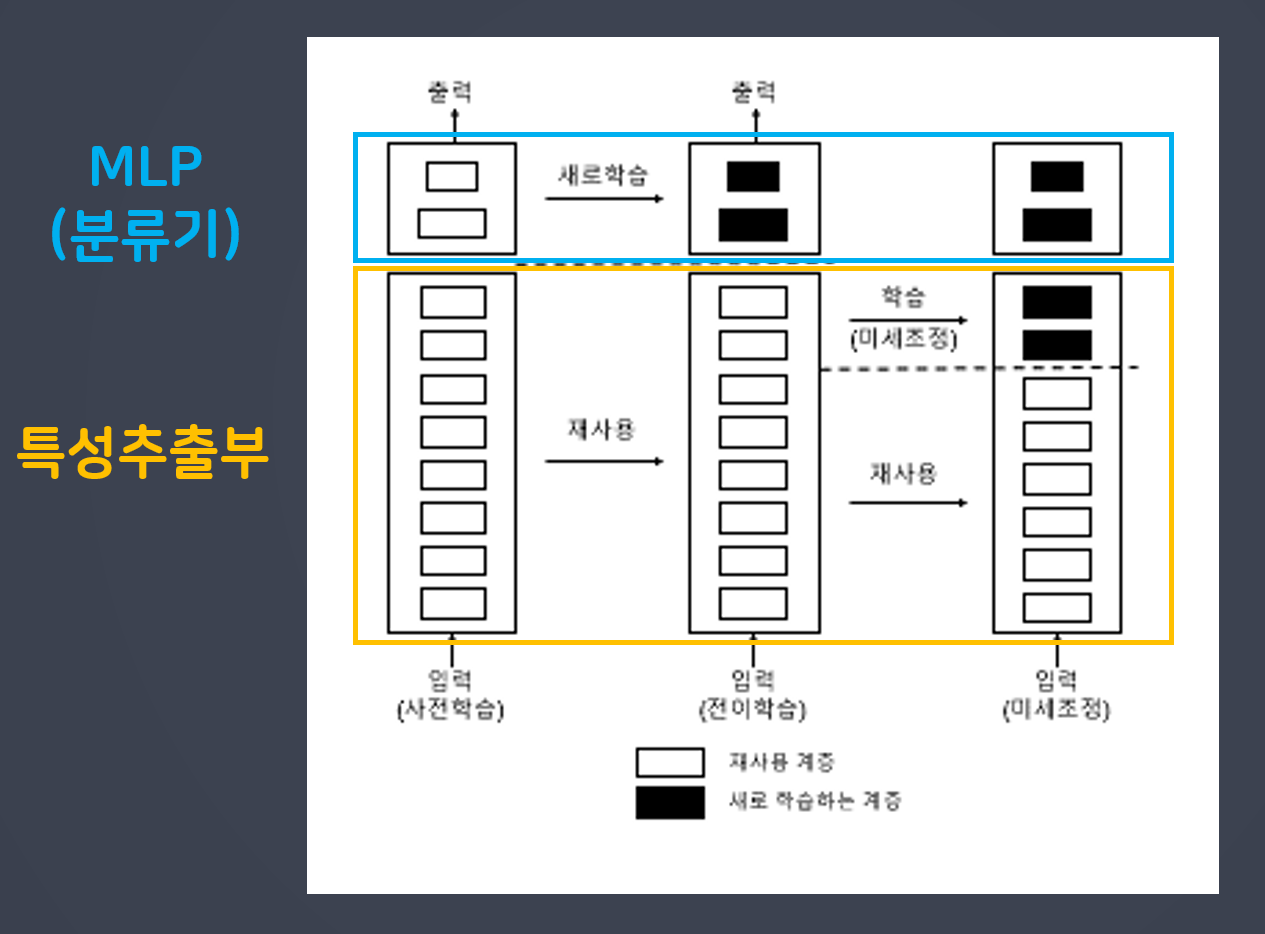

### VGG16 모델
- CNN 모델 구조, 이미지 분류용 신경망 모델
- imgNet 데이터셋 1000개 카테고리로 훈련된 모델 -> 약 1200만장 이상의 이미지로 학습 완료

In [1]:
# VGG16 모델불러오기
from tensorflow.keras.applications import VGG16

In [2]:
# VGG16: 사전학습된 모델
# 사전학습된 모델을 새롭게 학습시켜 분류 -> 전이학습
# 모델의 특성추출부만 불러서 확인~
vgg16 = VGG16(include_top= False, # 분류부를 포함할지 여부 -> False 미포함 (vgg16 기본 다중분류 1000개 class)
              weights = 'imagenet', # 이미지넷 데이터셋으로 학습한 가중치를 쓰겠다
              input_shape = (224,224,3)
              )

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
vgg16.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

### Conv층 미세조정
1. 원하는 층만 재학습 -> 재학습을 원하지 않는 층의 가중치 갱신을 막아주세요~!! (동결)
- VGG16 모델의 성능이 좋음!, 학습시 가중치가 갱신되도록 설정하면 기존학습된 내용 훼손 -> 성능이 떨어짐 -> 좋은 성능을 유지 -> 동결

In [5]:
# 모델 재학습 -> 신경망모델 설계
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D

# 뼈대생성
transfer_model = Sequential()
# 특성추출부
transfer_model.add(vgg16)
# 1차원변경
transfer_model.add(Flatten())
# 분류부
transfer_model.add(Dense(units = 64, activation='relu')) # 연산층, 중간층
# 출력층
transfer_model.add(Dense(units = 1, activation='sigmoid'))

In [6]:
transfer_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,320,449 (62.26 MB)

 Trainable params: 16,320,449 (62.26 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# 학습방법 및 평가방법 설정
transfer_model.compile(loss = 'binary_crossentropy',
                       optimizer = 'adam',
                       metrics = ['accuracy'])

In [9]:
# 미세조정 (Fine Tunning)
# 사전학습된 모델을 재학습하여 나의 새로운 데이터에 맞게끔 세밀조정
# 마지막 합성곱층 block5_conv3 층만을 나의 개고양이 데이터로 재학습

# 층이름 확인
vgg16.layers[1].name

'block1_conv1'

In [10]:
vgg16.layers

[<InputLayer name=input_layer, built=True>,
 <Conv2D name=block1_conv1, built=True>,
 <Conv2D name=block1_conv2, built=True>,
 <MaxPooling2D name=block1_pool, built=True>,
 <Conv2D name=block2_conv1, built=True>,
 <Conv2D name=block2_conv2, built=True>,
 <MaxPooling2D name=block2_pool, built=True>,
 <Conv2D name=block3_conv1, built=True>,
 <Conv2D name=block3_conv2, built=True>,
 <Conv2D name=block3_conv3, built=True>,
 <MaxPooling2D name=block3_pool, built=True>,
 <Conv2D name=block4_conv1, built=True>,
 <Conv2D name=block4_conv2, built=True>,
 <Conv2D name=block4_conv3, built=True>,
 <MaxPooling2D name=block4_pool, built=True>,
 <Conv2D name=block5_conv1, built=True>,
 <Conv2D name=block5_conv2, built=True>,
 <Conv2D name=block5_conv3, built=True>,
 <MaxPooling2D name=block5_pool, built=True>]

In [11]:
# 층이름.trainable = True -> 가중치 업데이트, False -> 동결
# 반복문을 통하여 특정 층만을 재학습(가중치 업데이트)
for layer in vgg16.layers:
  if layer.name == 'block5_conv3': # 층이름이 block5_conv3 라면 재학습 ㄱㄱ
    layer.trainable = True # 가중치 업데이트
  else:
    layer.trainable = False # 학습가중치 동결

In [16]:
# 학습
transfer_model.fit(X_train, y_train, validation_split=0.2, epochs= 10)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 49s 498ms/step - accuracy: 0.8981 - loss: 2.3302 - val_accuracy: 0.8450 - val_loss: 1.1132
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 265ms/step - accuracy: 0.9769 - loss: 0.1217 - val_accuracy: 0.9225 - val_loss: 0.5058
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 272ms/step - accuracy: 0.9831 - loss: 0.0535 - val_accuracy: 0.8900 - val_loss: 0.6415
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 280ms/step - accuracy: 0.9900 - loss: 0.0449 - val_accuracy: 0.9725 - val_loss: 0.1252
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 283ms/step - accuracy: 0.9894 - loss: 0.0478 - val_accuracy: 0.9825 - val_loss: 0.1805
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 280ms/step - accuracy: 0.9906 - loss: 0.0334 - val_accuracy: 0.9700 - val_loss: 0.2658
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 278ms/step - accuracy: 0.9887 - loss: 0.1207 - val_accuracy: 0.9625 - val_loss: 0.5476
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 277ms/step - accuracy: 0.9856 - loss: 0.1014 - val_accu

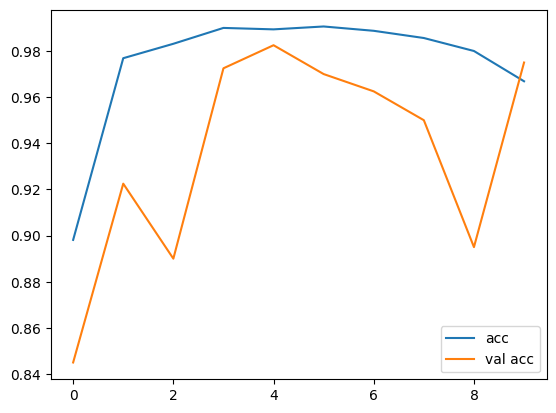

In [17]:
#시각화
plt.plot(transfer_model.history.history['accuracy'], label = 'acc')
plt.plot(transfer_model.history.history['val_accuracy'], label = 'val acc')
plt.legend()